In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.optimize import curve_fit


In [2]:
conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/00_connectomes_50.npy") 
dists = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/distance_matrix_50.npy")

In [3]:
ids = [0, 22, 103, 124, 169, 206]
ids_connectomes = ids
all_five_connectomes = conns[ids]  # shape (5,100,100)
all_five_distances = dists[ids]    # shape (5,100,100)

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_72949/1189560576.py:15: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_72949/1189560576.py:15: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x)
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_72949/1189560576.py:97: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(residuals, labels=[f"C{i}" for i in range(number_connectomes)])


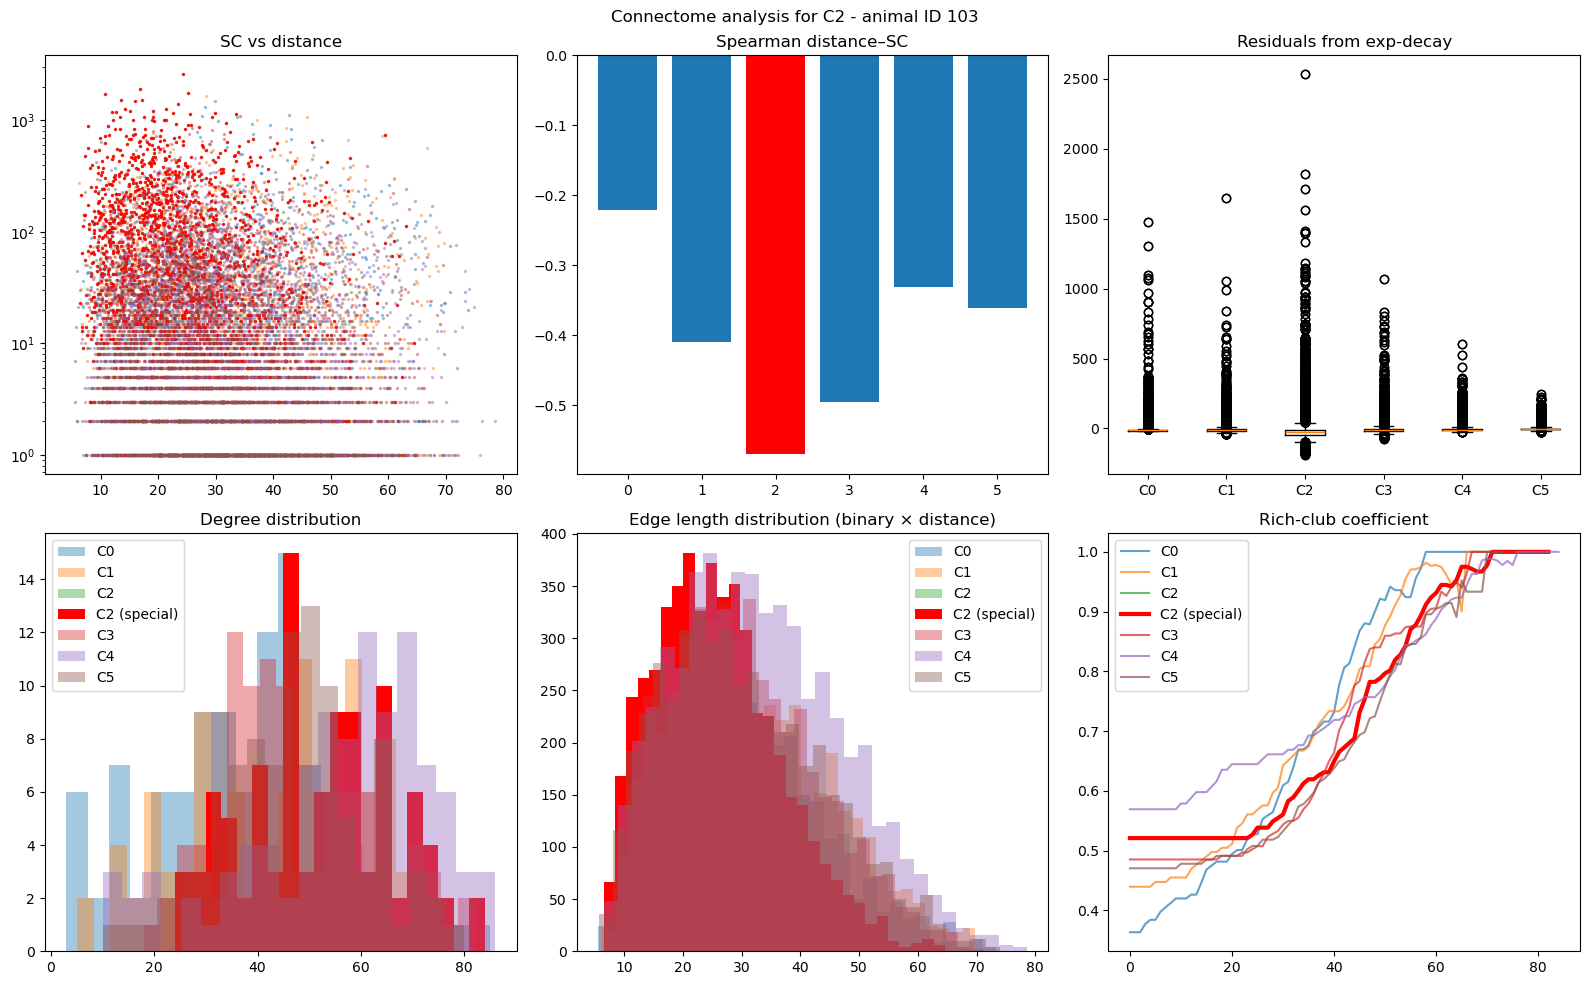

Spearman correlations: [np.float64(-0.22085619658612293), np.float64(-0.4094236812995113), np.float64(-0.5695404307422731), np.float64(-0.4948800015399313), np.float64(-0.33145661384637287), np.float64(-0.36107634615909473)]
Exponential decay params (a, b): [array([1.87725786e+01, 6.43313532e-03]), array([5.35224328e+01, 3.20438962e-02]), array([3.12271283e+02, 6.64266912e-02]), array([1.03654293e+02, 4.87029689e-02]), array([3.46985797e+01, 2.77130546e-02]), array([35.52203101,  0.04890836])]
Global efficiency: [0.6756228956228941, 0.7157575757575741, 0.7597979797979789, 0.7421212121212116, 0.7839393939393936, 0.7346127946127945]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.optimize import curve_fit
import networkx as nx

special_index = 2

# --- INPUT ---
C = all_five_connectomes        # shape (5,100,100), weighted or binary
D = all_five_distances          # shape (5,100,100)

# --- Helper ---
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

# --- Storage ---
spearman_scores = []
decay_params   = []
residuals      = []
degrees_all    = []
edge_lengths_all = []
strengths_all  = []
clustering_all = []
global_eff     = []
richclub_all   = []

plt.figure(figsize=(16,10))

# ======================================================
# EVALUATION FOR EACH CONNECTOME
# ======================================================
number_connectomes = C.shape[0]
for i in range(number_connectomes):
    Ci = C[i]
    Di = D[i]

    # Flatten without self-distances
    mask = Di > 0
    sc = Ci[mask]
    dist = Di[mask]

    # --- Spearman ---
    rho, _ = spearmanr(dist, sc)
    spearman_scores.append(rho)

    # --- Exponential fit ---
    popt, _ = curve_fit(exp_decay, dist, sc + 1e-6)
    decay_params.append(popt)
    residuals.append(sc - exp_decay(dist, *popt))

    # --- Degree distribution ---
    binary_graph = (Ci > 0).astype(int)
    deg = binary_graph.sum(axis=0)
    degrees_all.append(deg)

    # --- Strength distribution ---
    strengths_all.append(Ci.sum(axis=0))

    # --- Edge length distribution (binary mask × distance) ---
    edge_lengths = Di[binary_graph > 0]
    edge_lengths_all.append(edge_lengths)

    # --- Clustering coeff ---
    G = nx.from_numpy_array(Ci)
    clustering = np.array(list(nx.clustering(G, weight="weight").values()))
    clustering_all.append(clustering)

    # --- Global efficiency ---
    global_eff.append(nx.global_efficiency(G))

    # --- Rich club curve ---
    rc = nx.rich_club_coefficient(G, normalized=False)
    richclub_all.append(rc)

# ======================================================
# -------------------- PLOTTING ------------------------
# ======================================================

# 1. SC vs Distance
plt.subplot(2,3,1)
for i in range(number_connectomes):
    plt.scatter(D[i][D[i]>0], C[i][D[i]>0], s=2, alpha=0.2)
    if special_index == i:
        plt.scatter(D[i][D[i]>0], C[i][D[i]>0], s=2, alpha=0.5, color='red', label=f'C{i} (special)')
plt.yscale("log")
plt.title("SC vs distance")

# 2. Spearman correlations
plt.subplot(2,3,2)
plt.bar(range(number_connectomes), spearman_scores)
plt.bar(special_index, spearman_scores[special_index], color='red', label=f'C{special_index} (special)')
plt.title("Spearman distance–SC")

# 3. Residuals
plt.subplot(2,3,3)
plt.boxplot(residuals, labels=[f"C{i}" for i in range(number_connectomes)])

plt.title("Residuals from exp-decay")

# 4. Degree distributions
plt.subplot(2,3,4)
for i in range(number_connectomes):
    plt.hist(degrees_all[i], bins=20, alpha=0.4, label=f"C{i}")
    if special_index == i:
        plt.hist(degrees_all[i], bins=20, alpha=1, color='red', label=f"C{i} (special)")
plt.title("Degree distribution")
plt.legend()

# 5. Edge-length distributions
plt.subplot(2,3,5)
for i in range(number_connectomes):
    plt.hist(edge_lengths_all[i], bins=30, alpha=0.4, label=f"C{i}")
    if special_index == i:
        plt.hist(edge_lengths_all[i], bins=30, alpha=1, color='red', label=f"C{i} (special)")   
plt.title("Edge length distribution (binary × distance)")
plt.legend()

# 6. Rich-club curves
plt.subplot(2,3,6)
for i in range(number_connectomes):
    rc = richclub_all[i]
    ks = list(rc.keys())
    vals = list(rc.values())
    plt.plot(ks, vals, alpha=0.7, label=f"C{i}")
    if special_index == i:
        plt.plot(ks, vals, linewidth=3, alpha=1, color='red', label=f"C{i} (special)")
plt.title("Rich-club coefficient")
plt.legend()

plt.suptitle(f"Connectome analysis for C{special_index} - animal ID {ids_connectomes[special_index]}")

plt.tight_layout()
plt.show()

# -------------------------
# PRINT ADDITIONAL METRICS
# -------------------------
print("Spearman correlations:", spearman_scores)
print("Exponential decay params (a, b):", decay_params)
print("Global efficiency:", global_eff)


In [12]:
conns_diffusion = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_diffusion/01_connectomes/diffusion.npy")

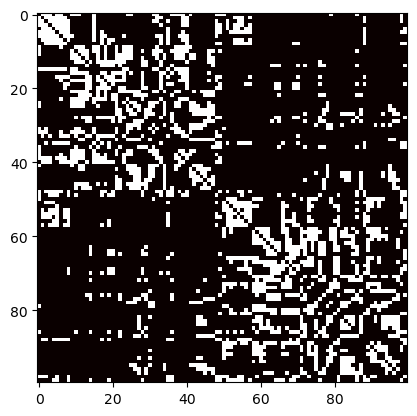

In [14]:
plt.imshow(conns_diffusion[:,:,0], cmap='hot', interpolation='nearest')